<a href="https://colab.research.google.com/github/Malekch09/GDP_prediction/blob/main/malek_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('world_bank_data_2025.csv')
target = 'Inflation (CPI %)'
print("Data loaded:", df.shape)
print("Year range:", df['year'].min(), "-", df['year'].max())

Data loaded: (3472, 16)
Year range: 2010 - 2025


In [118]:
numeric_cols = df.select_dtypes(include='number').columns
# First fill with country median
df[numeric_cols] = df.groupby('country_name')[numeric_cols].transform(lambda x: x.fillna(x.median()))
# Any leftover NaN → fill with global median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df = df.sort_values(['country_name', 'year']).reset_index(drop=True)
print("After cleaning:", df.shape)
print("Year range:", df['year'].min(), "-", df['year'].max())
print("Any NaN left?", df.isnull().sum().sum())

After cleaning: (3038, 52)
Year range: 2012 - 2025
Any NaN left? 0


In [119]:
exclude = [target, 'year', 'country_id']
features = [col for col in numeric_cols if col not in exclude]

for col in features:
    df[f'{col}_lag1'] = df.groupby('country_name')[col].shift(1)

# Drop the first year of each country (no lag available)
required_cols = [f'{col}_lag1' for col in features]
df = df.dropna(subset=required_cols).reset_index(drop=True)

print("After lag-1:", df.shape)
print("Year range now:", df['year'].min(), "-", df['year'].max())

After lag-1: (2604, 88)
Year range now: 2014 - 2025


In [120]:
lag_cols = [col for col in df.columns if '_lag1' in col]
X = df[lag_cols]
y = df[target]

print("X:", X.shape, "y:", y.shape)
assert len(X) == len(y), "Mismatch between X and y rows!"

X: (2604, 48) y: (2604,)


In [121]:
has_target = y.notna()
train_mask = (df['year'] <= 2019) & has_target
test_mask  = (df['year'] >= 2020) & has_target
future_mask = df['year'] == df['year'].max()   # 2025

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]
X_test  = X.loc[test_mask]
y_test  = y.loc[test_mask]
X_future = X.loc[future_mask]
future_countries = df.loc[future_mask, 'country_name'].reset_index(drop=True)

print("Train:", X_train.shape, "Test:", X_test.shape, "Future:", X_future.shape)
print("Train years:", sorted(df.loc[train_mask, 'year'].unique()))
print("Test years :", sorted(df.loc[test_mask, 'year'].unique()))
print("Future year:", df.loc[future_mask, 'year'].unique())

Train: (1302, 48) Test: (1302, 48) Future: (217, 48)
Train years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Test years : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Future year: [2025]


In [122]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_future_scaled = scaler.transform(X_future)
print("Scaling done.")

Scaling done.


In [123]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
print("Linear and Ridge trained.")

Linear and Ridge trained.


In [124]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)

print("===== TEST SET (2020‑2024) =====")
print(f"Linear Regression -> MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}, "
      f"R²: {r2_score(y_test, y_pred_lr):.3f}")
print(f"Ridge              -> MAE: {mean_absolute_error(y_test, y_pred_ridge):.3f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.3f}, "
      f"R²: {r2_score(y_test, y_pred_ridge):.3f}")

===== TEST SET (2020‑2024) =====
Linear Regression -> MAE: 10.078, RMSE: 41.554, R²: -2.387
Ridge              -> MAE: 9.913, RMSE: 41.342, R²: -2.352


In [125]:
future_preds = pd.DataFrame({'country_name': future_countries})
future_preds['LR_2027'] = lr.predict(X_future_scaled)
future_preds['Ridge_2027'] = ridge.predict(X_future_scaled)

print("===== FIRST 5 FORECASTS (2027) =====")
print(future_preds[['country_name', 'LR_2027', 'Ridge_2027']].head())

===== FIRST 5 FORECASTS (2027) =====
     country_name    LR_2027  Ridge_2027
0     Afghanistan   4.737928    4.824384
1         Albania   4.787485    4.740163
2         Algeria  11.149206   10.857349
3  American Samoa   5.068103    5.069567
4         Andorra   8.447704    8.567253


In [126]:
top_lr = future_preds.nlargest(10, 'LR_2027')
top_ridge = future_preds.nlargest(10, 'Ridge_2027')

print("===== TOP 10 (Linear Regression) =====")
print(top_lr[['country_name', 'LR_2027']].to_string(index=False))

print("\n===== TOP 10 (Ridge) =====")
print(top_ridge[['country_name', 'Ridge_2027']].to_string(index=False))

tunisia = future_preds[future_preds['country_name'].str.contains('Tunisia', case=False)]
if not tunisia.empty:
    total = len(future_preds)
    for col in ['LR_2027', 'Ridge_2027']:
        val = tunisia[col].values[0]
        rank = (future_preds[col] > val).sum() + 1
        print(f"Tunisia ({col}): {val:.2f}%  (Rank {rank}/{total})")
else:
    print("Tunisia not found – check country name spelling.")

===== TOP 10 (Linear Regression) =====
        country_name     LR_2027
            Zimbabwe 1007.865357
               Sudan  243.438080
           Argentina  144.850575
             Turkiye   85.451471
       United States   69.824732
Syrian Arab Republic   44.845503
               China   41.747212
         South Sudan   38.762221
            Ethiopia   38.669781
       Venezuela, RB   38.057424

===== TOP 10 (Ridge) =====
        country_name  Ridge_2027
            Zimbabwe 1003.189701
               Sudan  242.873052
           Argentina  143.843247
             Turkiye   84.177539
Syrian Arab Republic   45.237425
       United States   41.633176
         South Sudan   38.507835
            Ethiopia   38.346623
       Venezuela, RB   37.995434
               Ghana   37.486740
Tunisia (LR_2027): 10.77%  (Rank 59/217)
Tunisia (Ridge_2027): 10.59%  (Rank 56/217)


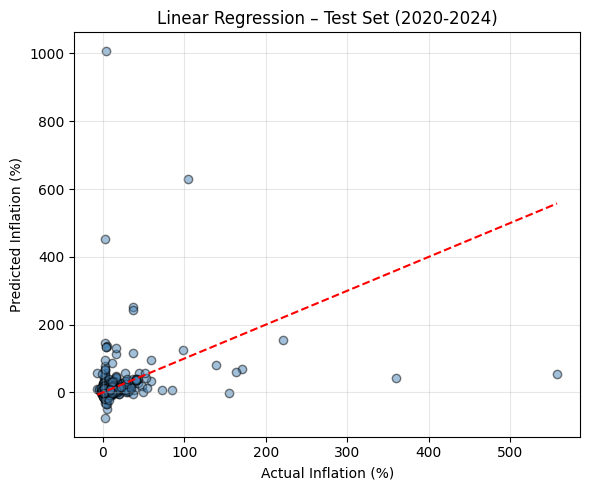

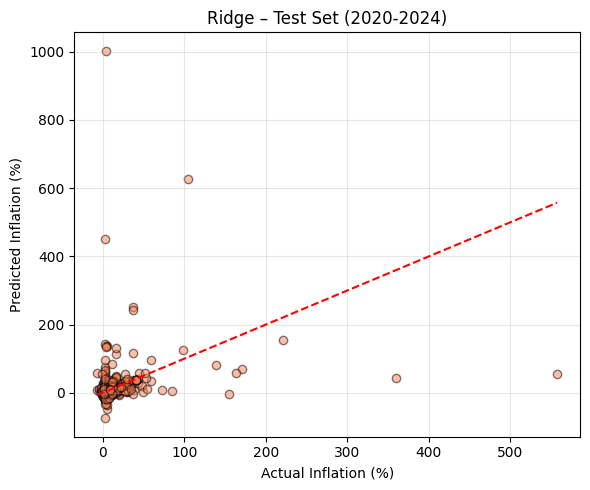

In [127]:
# Linear Regression
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Inflation (%)')
plt.ylabel('Predicted Inflation (%)')
plt.title('Linear Regression – Test Set (2020‑2024)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Ridge
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='coral', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Inflation (%)')
plt.ylabel('Predicted Inflation (%)')
plt.title('Ridge – Test Set (2020‑2024)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

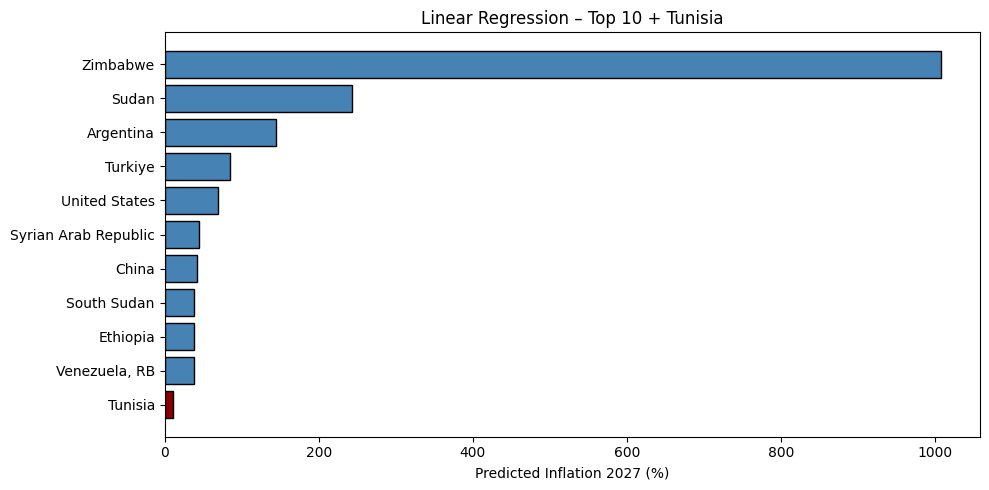

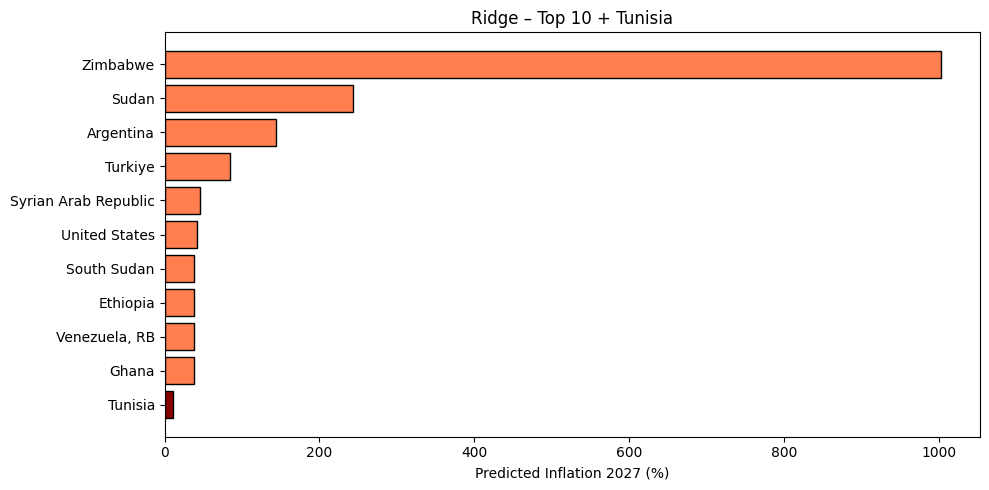

In [128]:
# ----- Linear Regression bar chart -----
plot_lr = top_lr.copy()
if not tunisia.empty and tunisia['country_name'].values[0] not in plot_lr['country_name'].values:
    plot_lr = pd.concat([plot_lr, tunisia])
plot_lr = plot_lr.sort_values('LR_2027', ascending=True)

plt.figure(figsize=(10,5))
colors = ['darkred' if 'Tunisia' in c else 'steelblue' for c in plot_lr['country_name']]
plt.barh(plot_lr['country_name'], plot_lr['LR_2027'], color=colors, edgecolor='black')
plt.xlabel('Predicted Inflation 2027 (%)')
plt.title('Linear Regression – Top 10 + Tunisia')
plt.tight_layout()
plt.show()

# ----- Ridge bar chart -----
plot_ridge = top_ridge.copy()
if not tunisia.empty and tunisia['country_name'].values[0] not in plot_ridge['country_name'].values:
    plot_ridge = pd.concat([plot_ridge, tunisia])
plot_ridge = plot_ridge.sort_values('Ridge_2027', ascending=True)

plt.figure(figsize=(10,5))
colors = ['darkred' if 'Tunisia' in c else 'coral' for c in plot_ridge['country_name']]
plt.barh(plot_ridge['country_name'], plot_ridge['Ridge_2027'], color=colors, edgecolor='black')
plt.xlabel('Predicted Inflation 2027 (%)')
plt.title('Ridge – Top 10 + Tunisia')
plt.tight_layout()
plt.show()